## Dataset Provenance and Scientific Context

The CRCNS PVC-2 dataset used in this notebook contains extracellular spike recordings from neurons in the **primary visual cortex (V1) of anesthetized cats**, collected in the laboratory of **Yang Dan (UC Berkeley)**. These recordings were used in influential studies on how cortical neurons encode visual stimuli.

Two key publications based on this dataset are:

### 1. Touryan, Lau & Dan (2002) — *Isolation of relevant visual features from random stimuli for cortical complex cells*  
**Journal of Neuroscience, 22, 10811–10818**

This study used random stimulus ensembles and spike-triggered covariance methods to identify the stimulus features that drive **complex cells** in V1. It demonstrated that nonlinear receptive field components of cortical neurons can be recovered directly from spike responses.

### 2. Touryan, Felsen & Dan (2005) — *Spatial Structure of Complex Cell Receptive Fields Measured with Natural Images*  
**Neuron, 45, 781–791**

This later work extended the analysis to **natural image stimuli**, showing that complex-cell receptive fields can be described by a small number of oriented subunits. The results supported the classical **energy model** of visual cortical processing and provided an early example of nonlinear neural encoding under naturalistic stimulation.

## Why this dataset matters

This dataset is historically important because it helped establish modern approaches for studying neural coding using:

- spike-triggered average (STA)
- spike-triggered covariance (STC)
- nonlinear receptive field estimation
- natural stimulus encoding models

It remains highly relevant today for comparing classical neuroscience methods with modern machine learning models such as GLMs, CNNs, and neural system identification networks.

Based on archived correspondence from the original investigators, filenames encode:

YYMMDD.(chamber).(penetration)(cell number)(run number)(stimulus).(filetype)

Thus files such as `000413.b03bmsq1D.sa0`, `000413.b03cmsq1D.sa0`, and `000413.b03dmsq1D.sa0` correspond to the same recorded unit (`b03`) across different sequential runs (`b`, `c`, `d`) using the `msq1D` stimulus.

For the `msq1D` white-noise experiments, the `.log` field `StiW` specifies the stimulus width on the display in centimeters. The viewing distance was 114 cm, so 1 cm corresponds to approximately 0.5° of visual angle. Since the stimulus contains 16 bars, the spatial width of each bar is `StiW / 16` cm (≈ `0.5 * StiW / 16` degrees). The stimulus coordinate system was aligned to each neuron's preferred orientation and direction.

When plotting STA/STC filters, label x-axis as:

Position (deg visual angle)

using StiW.

That makes the notebook publication-quality.

- imsq1D.mat = temporal sequence of bar patterns

From the dataset documentation:

msq1D.mat = 1D M-sequence stimulus with 16 bars, 32767 frames
imsq1D.mat = inverted M-sequence stimulus with 512 frames

This gives you:

X = stimulus matrix (known input)
y = spikes (neural output)

That is a supervised learning problem.

You can fit:

linear receptive fields
Poisson GLMs
CNNs
RNNs
temporal filters

In [82]:
from pathlib import Path
import numpy as np
from src import (retrieve_log, tori,
                 load_log_lines, numbers,
                 search_log, load_spikes)

from scipy.io import loadmat
import os
import matplotlib.pyplot as plt

### settings for the project

In [83]:
#setting for the experiment

PROJECT_ROOT = Path.cwd()
DATA_ROOT=PROJECT_ROOT/'data'/'crcns-pvc2'
root =DATA_ROOT / "1D_white_noise/Spike_and_Log_Files"

the first priority after isolating a neuron is to determine what kind of stimulus drives it best. The tuning run is therefore usually performed first as a calibration and characterization step.

For V1 neurons, especially in cat primary visual cortex, responses depend strongly on stimulus orientation, spatial frequency, position, contrast, and motion. If you do not know these preferences first, later experiments may be inefficient or even misleading.



In [84]:
def is_it_complex(directory, plot=False):

    for folder in os.listdir(directory):
        folder_path = os.path.join(directory, folder)
        
        tune_logs = [
            f for f in os.listdir(folder_path)
            if f.endswith("tune.log")
        ]

        first_file = sorted(tune_logs)[0]

        
        
        flog = retrieve_log(
        path=root/folder,
        filename=first_file,
        channels=None
    )

        info = tori(flog, cluster_index=0, plot=plot)

        relmod = info["relmod"]

        if relmod > 1.0:
            cell_type = "simple / linear-like"
        else:
            cell_type = "complex / nonlinear-like"

        print(f"cell {first_file} is {cell_type}, relmod = {relmod}")

    
is_it_complex(root)
    

        
        


cell 000412.a01atune.log is complex / nonlinear-like, relmod = 0.33330387530427197
cell 000413.b03atune.log is complex / nonlinear-like, relmod = 0.7116498828292331
cell 000413.b04atune.log is complex / nonlinear-like, relmod = 0.21339725189230435
cell 000413.b05atune.log is complex / nonlinear-like, relmod = 0.19707725254638003
cell 000418.a01atune.log is complex / nonlinear-like, relmod = 0.7083067009830974
cell 000419.a06gtune.log is complex / nonlinear-like, relmod = 0.3058788924566454
cell 000419.a07atune.log is complex / nonlinear-like, relmod = 0.5679200312660044
cell 000419.a09itune.log is complex / nonlinear-like, relmod = 0.42749188852456366
cell 000420.b02atune.log is simple / linear-like, relmod = 1.8052012990662298
cell 000503.a03atune.log is complex / nonlinear-like, relmod = 0.2937789838281495
cell 000511.b09ntune.log is complex / nonlinear-like, relmod = 0.5019446695753919
cell 000511.b10otune.log is complex / nonlinear-like, relmod = 0.323404839560468
Correcting spike 

In [85]:
COMPLEX_NEURON_PATH= root/'000413.b03'

LINEAR_NEURON_PATH=root/'000420.b02'

STIM_PATH  = DATA_ROOT/'1D_white_noise/Stimulus_Files/msq1D.mat'


filenames_complex = [
    
    '000413.b03bmsq1D.sa0',
    '000413.b03cmsq1D.sa0',
    '000413.b03dmsq1D.sa0',
    '000413.b03fmsq1D.sa0',
    '000413.b03hmsq1D.sa0',
]


filenames_linear=[
    '000420.b02bmsq1d.sa0',
    '000420.b02cmsq1d.sa0',
    '000420.b02dmsq1d.sa0',
    '000420.b02emsq1d.sa0',
    '000420.b02fmsq1d.sa0',
    '000420.b02gmsq1d.sa0',
    '000420.b02hmsq1d.sa0'

]


paths_comples_trials = [COMPLEX_NEURON_PATH / name for name in filenames_complex]
paths_linear_trial = [LINEAR_NEURON_PATH / name for name in filenames_linear]






### neuron b03 of 2000

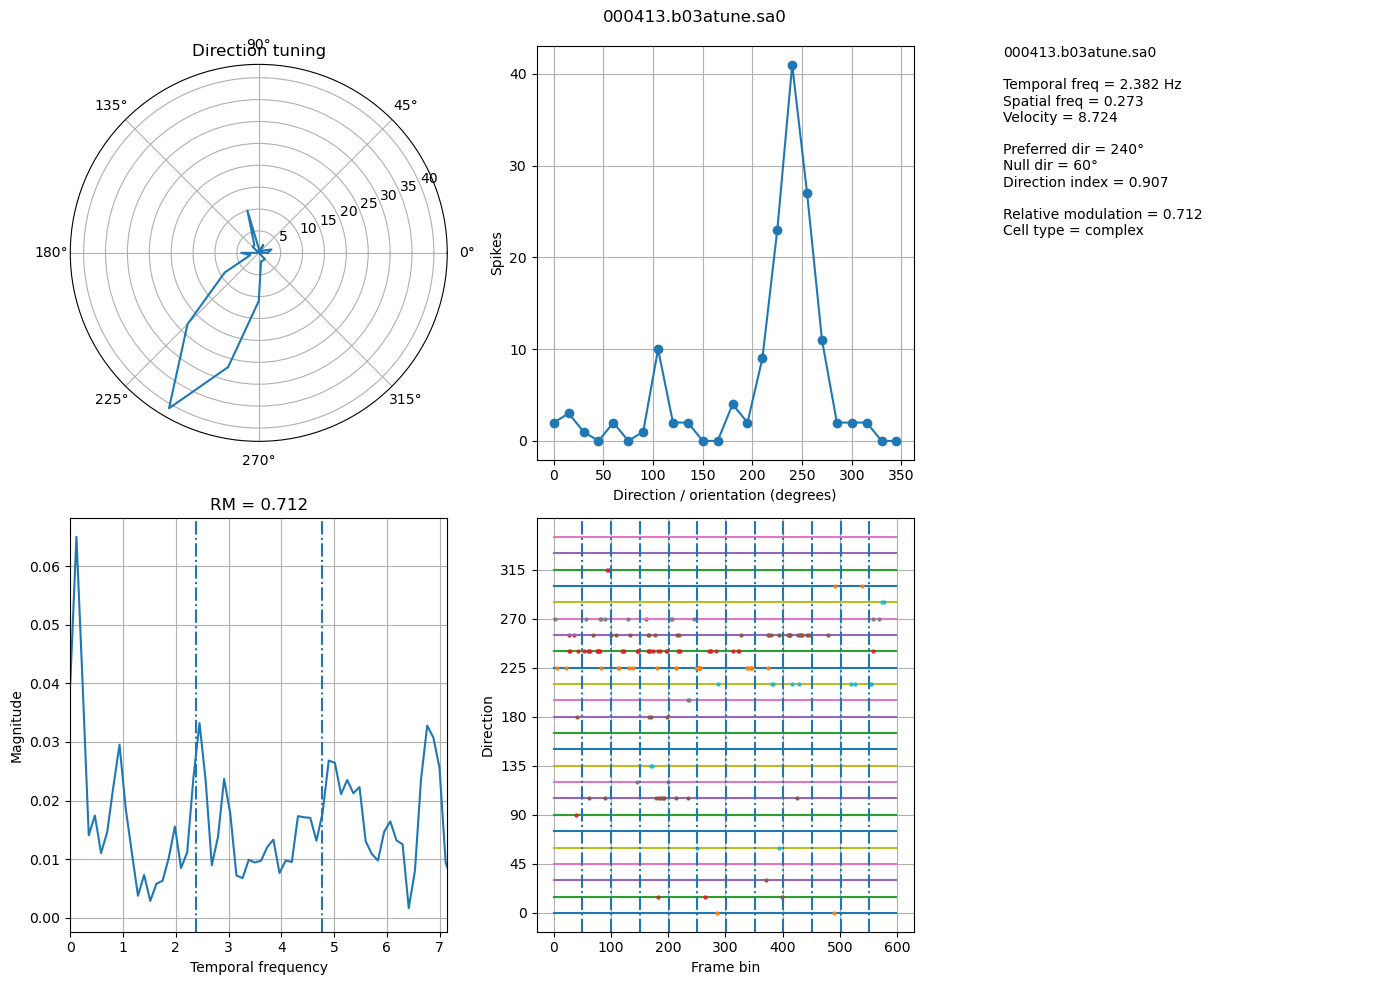

In [86]:
flog = retrieve_log(
    path=COMPLEX_NEURON_PATH,
    filename="000413.b03atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)




In [87]:

for path in paths_comples_trials:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines(path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    print(f'Stimulus: {msq1D_stim.shape}  (frames × bars)')
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


### neuron b02 of 2004

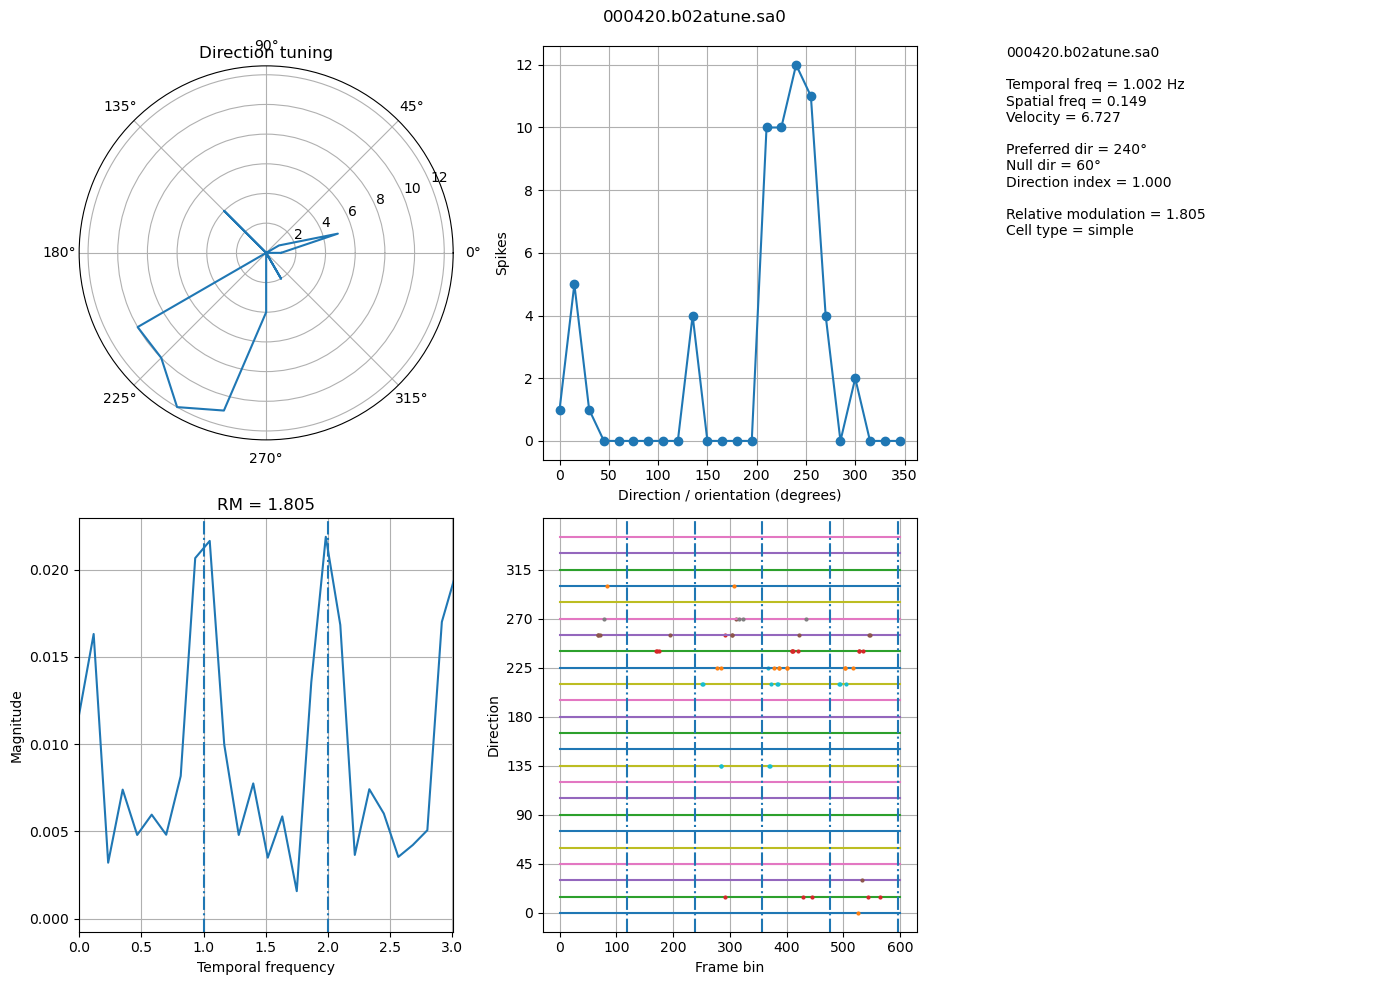

In [88]:
flog = retrieve_log(
    path=LINEAR_NEURON_PATH,
    filename="000420.b02atune.log",
    channels=None
)

info = tori(flog, cluster_index=0, plot=True)
paths = [LINEAR_NEURON_PATH / name for name in filenames_complex]


msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1




In [89]:
for path in paths_linear_trial:


    msq1D_stim = loadmat(STIM_PATH)['msq1D'].astype(float)   # (32767, 16), values ±1


    log_lines         = load_log_lines( path)
    remote_rr         = float(numbers(search_log(log_lines, 'TestInfo',  'RemoteRefreshRate', '119.44'))[0])
    frame_rate_factor = float(numbers(search_log(log_lines, 'TestInfo',  'FrameRateFactor',   '2'))[0])
    sti_w             = float(numbers(search_log(log_lines, 'Stimulus',  'StiW',              '9.0'))[0])

    frame_rate = remote_rr / frame_rate_factor    # effective stimulus update rate, ~59.72 Hz
    sti_w_deg  = sti_w * 0.5                      # cm → degrees (1 cm ≈ 0.5° at 114 cm viewing)


    print(f'Stimulus: {msq1D_stim.shape}  (frames × bars)')
    print(f'Effective frame rate: {frame_rate:.4f} Hz')
    print(f'Stimulus width: {sti_w} cm = {sti_w_deg:.2f}°  ({sti_w_deg / 16:.3f}°/bar)')

Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)
Stimulus: (32767, 16)  (frames × bars)
Effective frame rate: 59.7200 Hz
Stimulus width: 9.0 cm = 4.50°  (0.281°/bar)


In [90]:
from pathlib import Path



p = Path(r"C:\Users\aless\Desktop\neural_encoding\data\crcns-pvc2/1D_white_noise/Spike_and_Log_Files/000413.b03/000413.b03bmsq1D.Sa0")  # adjust path if needed

print("Exists:", p.exists())
print("Size:", p.stat().st_size, "bytes")

with open(p, "rb") as f:    ########### TO ADJUST, BUT WE NEED THE HEADERS 
    head = f.read(64)

print(head)




Exists: True
Size: 3264 bytes
b'DAN_SPK\x00\x00\x00\x00\x00\x00\x00\x00\x001.0\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00000413.b03bmsq1D.sa0\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'


In [91]:
from pathlib import Path
import numpy as np

path = Path(
    r"C:\Users\aless\Desktop\neural_encoding\data\crcns-pvc2\1D_white_noise\Spike_and_Log_Files\000413.b03\000413.b03bmsq1D.Sa0"
)

spike_times_raw = np.fromfile(path, dtype="<i4", offset=1024)
spike_times_sec = spike_times_raw / 10000.0

print("Number of spikes:", len(spike_times_sec))
print("First spike:", spike_times_sec[0], "s")
print("Last spike:", spike_times_sec[-1], "s")
print("Duration covered:", spike_times_sec[-1] - spike_times_sec[0], "s")

Number of spikes: 560
First spike: 50.9375 s
Last spike: 543.9536 s
Duration covered: 493.01610000000005 s


In [92]:
from pathlib import Path
import numpy as np
import struct


SPK_HEADER_SIZE = 828


def _read_c_string(raw: bytes) -> str:
    """
    Decode fixed-width MATLAB-style char fields.
    Removes trailing nulls, spaces, and newlines.
    """
    return raw.split(b"\x00", 1)[0].decode("ascii", errors="replace").strip()


def fget_hdr_python(path):
    path = Path(path)
    raw = path.read_bytes()

    if len(raw) < SPK_HEADER_SIZE:
        raise ValueError(f"{path.name}: file is too small to contain a full header")

    pos = 0

    def read_chars(n):
        nonlocal pos
        out = _read_c_string(raw[pos:pos + n])
        pos += n
        return out

    def read_int32():
        nonlocal pos
        value = struct.unpack_from("<i", raw, pos)[0]
        pos += 4
        return value

    file_info = {
        "Type": read_chars(16),
        "Version": read_chars(16),
        "Fname": read_chars(128),
        "Creator": read_chars(128),
        "Time": read_chars(32),
    }

    if file_info["Type"] != "DAN_SPK":
        raise ValueError(f"{path.name}: bad file type {file_info['Type']!r}")

    pos += 64  # reserved

    data_info = {
        "ID": read_chars(128),
        "DataFrom": read_chars(128),
        "Channel": read_int32(),
        "SampleRate": read_int32(),
        "Gain": read_int32(),
        "DAQMode": read_int32(),
        "DAQResolution": read_int32(),
        "DataType": read_int32(),
        "DataUnit": read_int32(),
        "TimeMode": read_int32(),
        "TimeOffset": read_int32(),
        "ThreshPeakHigh": read_int32(),
        "ThreshPeakLow": read_int32(),
        "ThreshValleyHigh": read_int32(),
        "ThreshValleyLow": read_int32(),
        "ThreshWidthMax": read_int32(),
        "ThreshWidthMin": read_int32(),
    }

    pos += 128  # reserved

    assert pos == SPK_HEADER_SIZE

    return {
        "FileInfo": file_info,
        "DataInfo": data_info,
    }

def fget_spk_python(path, sample_rate=None, return_header=True):
    path = Path(path)
    raw = path.read_bytes()

    name = path.name.lower()

    if "mq" in name or "film02" in name or "film32" in name:
        dtype = np.dtype("<u4")  # MATLAB uint32, little-endian
    else:
        dtype = np.dtype("<i4")  # MATLAB int32, little-endian

    has_header = b"DAN_SPK" in raw[:16]

    if has_header:
        hdr = fget_hdr_python(path)
        events = np.frombuffer(raw[SPK_HEADER_SIZE:], dtype=dtype)
    else:
        hdr = None
        events = np.frombuffer(raw, dtype=dtype)

    if sample_rate is None:
        if hdr is not None and hdr["DataInfo"]["SampleRate"] > 0:
            sample_rate = hdr["DataInfo"]["SampleRate"]
        else:
            sample_rate = 10000

    spike_times_sec = events.astype(float) / sample_rate

    if return_header:
        return events, spike_times_sec, hdr
    else:
        return events, spike_times_sec

Spike count: 583
First 10 events: [  3914   3930  40481  42780  44460  44489  83092 115928 159197 166355]


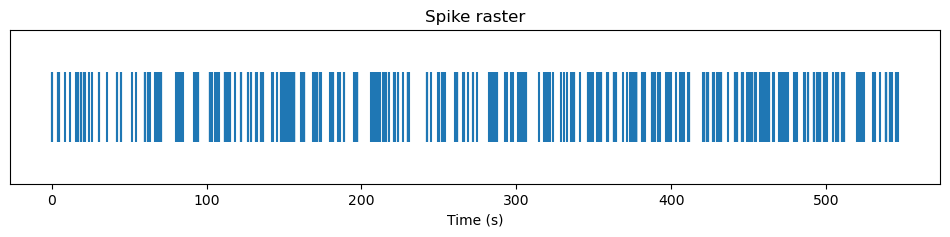

Spike count: 645
First 10 events: [ 75726 102368 259150 262400 270362 309654 315127 316941 317004 333238]


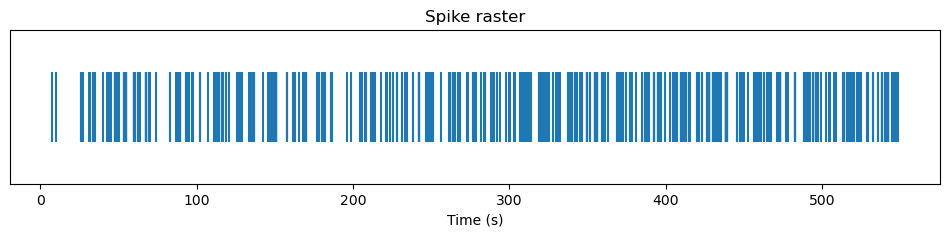

Spike count: 645
First 10 events: [ 28666  34303 111487 140452 141307 146699 160683 187953 236980 241236]


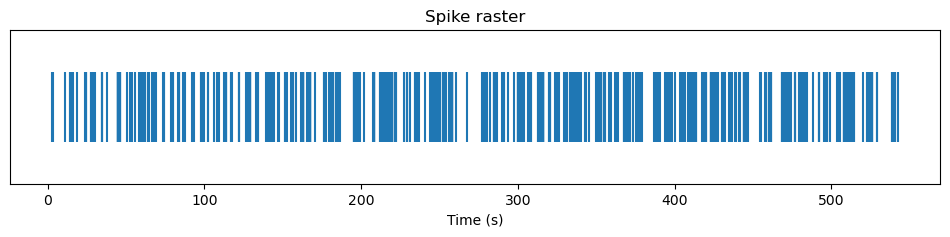

Spike count: 875
First 10 events: [ 5785 17271 17341 17366 18079 46818 94484 94591 97884 98682]


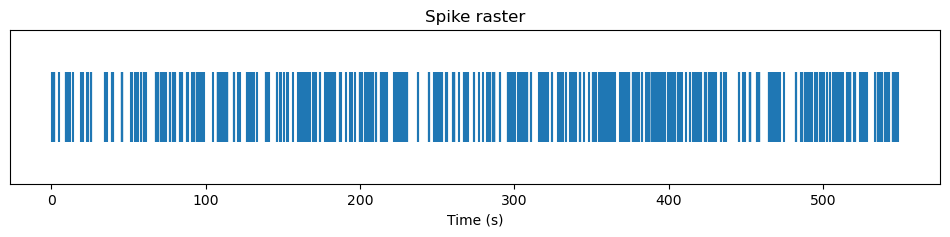

Spike count: 802
First 10 events: [ 3266  3354  5783 11755 17340 17354 44252 44370 62972 63015]


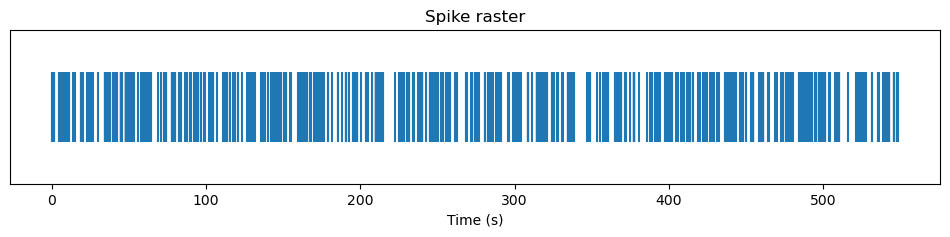

Spike count: 908
First 10 events: [152768 153151 190872 190953 190976 191698 192700 197958 198209 198246]


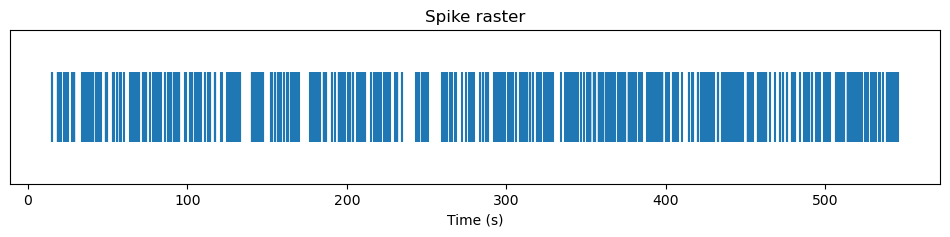

Spike count: 1183
First 10 events: [ 1271  1302 10566 18150 18294 23538 31619 96884 96931 96953]


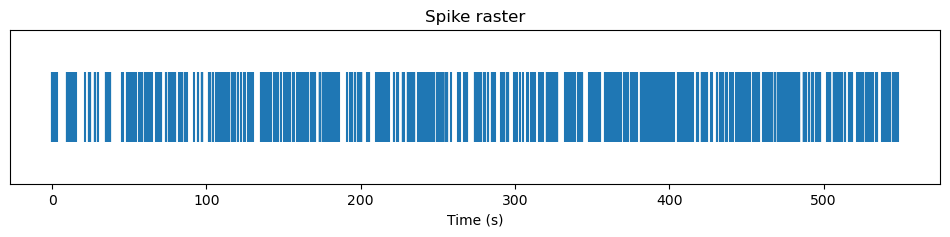

In [93]:
for path in paths_linear_trial:
    

    events, spike_times_sec, hdr = fget_spk_python(path)

    print("Spike count:", len(events))
    print("First 10 events:", events[:10])




    plt.figure(figsize=(12, 2))
    plt.eventplot(spike_times_sec, lineoffsets=1, linelengths=0.8)

    plt.xlabel("Time (s)")
    plt.yticks([])
    plt.title("Spike raster")
    plt.show()

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


def gaussian_rate_convolution(spike_times, t_start=None, t_end=None, dt=0.001, sigma=0.2):
    """
    Gaussian-smoothed firing rate using binning + convolution.

    spike_times : spike times in seconds
    dt          : bin width in seconds
    sigma       : Gaussian std in seconds

    returns:
        t        : time axis
        rate     : firing rate in spikes/s
        counts   : binned spike counts
    """
    spike_times = np.asarray(spike_times)

    if t_start is None:
        t_start = spike_times[0]
    if t_end is None:
        t_end = spike_times[-1]

    bins = np.arange(t_start, t_end + dt, dt)
    counts, edges = np.histogram(spike_times, bins=bins)

    # Convert sigma from seconds to bins
    sigma_bins = sigma / dt

    # Smooth spike counts
    smoothed_counts = gaussian_filter1d(
        counts.astype(float),
        sigma=sigma_bins,
        mode="constant"
    )

    # Convert counts/bin to spikes/second
    rate = smoothed_counts / dt

    # Bin centers
    t = edges[:-1] + dt / 2

    return t, rate, counts

In [95]:

# NOTE THIS IS FOR NOW JUST THE LAST TRIAL, SINCE THERE IS A FOR LOOP ABOVE 

for sigma in [ 0.5,1,2]:
    t, rate, _ = gaussian_rate_convolution(spk_sec, dt=0.001, sigma=sigma)

    plt.figure(figsize=(12, 3))
    plt.plot(t, rate)
    plt.title(f"Gaussian-smoothed rate, sigma = {sigma}s")
    plt.xlabel("Time (s)")
    plt.ylabel("spikes/s")
    plt.show()

NameError: name 'spk_sec' is not defined

In [ ]:
#plt.imshow(msq1D.T, aspect='auto', cmap='gray')

# to do 

- STA 
- OPTIMAL KERNEL 

the standard method used to determine the optimal kernel is to measure the spike-triggered average stimulus in response to a white-noise stimulus.

- STATIC NONLINEARITY

- BETTER TUNING CURVE 

- POISSON?????

# Spike-Triggered Average (STA)

In [ ]:
n_lags = 25  # frames (~419 ms at 59.72 Hz)


def compute_sta(spike_files, stim, n_lags, frame_rate):
    T, N        = stim.shape
    lag_offsets = np.arange(1, n_lags + 1)       # [1, 2, ..., n_lags]; row 0 = most recent
    sta_accum   = np.zeros((n_lags, N))
    n_total     = 0

    for path in spike_files:
        _, spk_sec, _ = fget_spk_python(path) 
        frames = np.floor(spk_sec * frame_rate).astype(int)
        valid  = (frames >= n_lags) & (frames < T)
        frames = frames[valid]

        windows    = frames[:, np.newaxis] - lag_offsets[np.newaxis, :]   # (n_spikes, n_lags)
        sta_accum += stim[windows].sum(axis=0)                            # (n_lags, N)
        n_total   += len(frames)
        

    print(f'\nTotal spikes used: {n_total}')
    return sta_accum / n_total, n_total



In [ ]:
print(msq1D_stim.mean())
print(msq1D_stim.mean(axis=0))  # if the mean is approx 0 we dont need to subtract it 

3.051850947599719e-05
[3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05
 3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05
 3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05
 3.05185095e-05 3.05185095e-05 3.05185095e-05 3.05185095e-05]


In [ ]:
sta, n_spikes = compute_sta(paths_linear_trial, msq1D_stim, n_lags, frame_rate)
print(f'STA shape: {sta.shape}  (lags × bars)')


Total spikes used: 5635
STA shape: (25, 16)  (lags × bars)


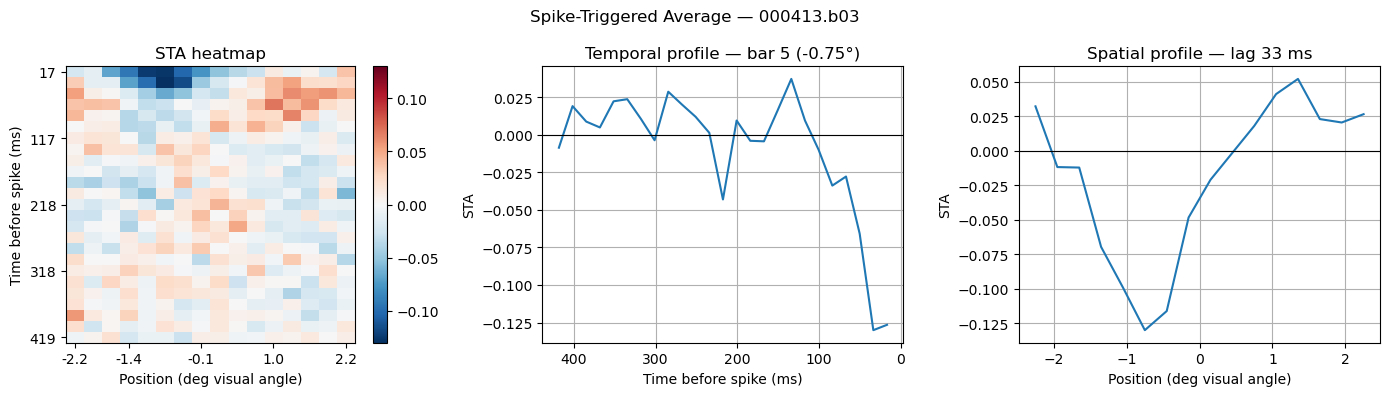

In [ ]:
bar_positions = np.linspace(-sti_w_deg / 2, sti_w_deg / 2, 16)   # bar centres in degrees
lags_ms       = np.arange(1, n_lags + 1) / frame_rate * 1000      # ms before spike

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Spike-Triggered Average — 000413.b03')

# Spatiotemporal heatmap
ax = axes[0]
vmax = np.abs(sta).max()
im   = ax.imshow(sta, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                 interpolation='nearest', origin='upper')
xtick_idx = np.linspace(0, 15, 5).astype(int)
ax.set_xticks(xtick_idx)
ax.set_xticklabels([f'{bar_positions[i]:.1f}' for i in xtick_idx])
ax.set_xlabel('Position (deg visual angle)')
ytick_idx = np.linspace(0, n_lags - 1, 5).astype(int)
ax.set_yticks(ytick_idx)
ax.set_yticklabels([f'{lags_ms[i]:.0f}' for i in ytick_idx])
ax.set_ylabel('Time before spike (ms)')
ax.set_title('STA heatmap')
plt.colorbar(im, ax=ax)

# Temporal profile at peak spatial position
ax = axes[1]
peak_bar = int(np.abs(sta).max(axis=0).argmax())
ax.plot(lags_ms, sta[:, peak_bar])
ax.axhline(0, color='k', linewidth=0.8)
ax.invert_xaxis()
ax.set_xlabel('Time before spike (ms)')
ax.set_ylabel('STA')
ax.set_title(f'Temporal profile — bar {peak_bar} ({bar_positions[peak_bar]:.2f}°)')
ax.grid(True)

# Spatial profile at peak lag
ax = axes[2]
peak_lag = int(np.abs(sta).max(axis=1).argmax())
ax.plot(bar_positions, sta[peak_lag])
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Position (deg visual angle)')
ax.set_ylabel('STA')
ax.set_title(f'Spatial profile — lag {lags_ms[peak_lag]:.0f} ms')
ax.grid(True)

plt.tight_layout()
plt.show()

## Optimal Kernel Estimation



In [ ]:
T, N = msq1D_stim.shape
recording_duration = T / frame_rate
mean_firing_rate = n_spikes / recording_duration
stim_variance = np.var(msq1D_stim)

kernel = mean_firing_rate * sta / stim_variance
print(f'STA shape: {sta.shape}  (lags × bars)')
print(f'kernel shape:{kernel.shape}')

STA shape: (25, 16)  (lags × bars)
kernel shape:(25, 16)


In [ ]:
kernel[3]

array([ 0.37727104,  0.40278695,  0.38091617, -0.041919  , -0.3262392 ,
       -0.28614277,  0.00911283, -0.11117649,  0.04556413,  0.07472518,
        0.3845613 ,  0.71262307,  0.4210126 ,  0.59962401,  0.2424012 ,
        0.13304727])

In [ ]:
msq1D_stim[-1]

array([-1.,  1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1., -1., -1., -1.,
        1.,  1.,  1.])

In [96]:
def compute_r_estimate(stim, kernel):
    T, N = stim.shape
    n_lags, N_kernel = kernel.shape

    assert N == N_kernel

    r_est = np.full(T, np.nan)

    for t in range(n_lags, T):
        total = 0.0

        for lag in range(n_lags):
            stimulus_frame = stim[t - lag - 1]
            kernel_frame = kernel[lag]

            total += np.sum(stimulus_frame * kernel_frame)

        r_est[t] = total

    return r_est
    

    

In [ ]:
train_files = paths_linear_trial[:5]
test_files  = paths_linear_trial[5:]



In [97]:
sta_train,n_train = compute_sta(train_files, msq1D_stim, n_lags, frame_rate)


Total spikes used: 2746


In [98]:
kernel = mean_firing_rate * sta_train / stim_variance

In [99]:
r_est=compute_r_estimate(msq1D_stim, kernel)

In the 2005 Neuron paper, they again emphasize that ordinary STA is useful for simple/linear receptive fields but inadequate for complex cells

# continue from here 

In [ ]:
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

# ── dimensions ───────────────────────────────────────────────────────────────
          # 32767, 16
n_features = n_lags * N_bars            # 400
T_eff      = T - n_lags                 # 32742 frames per run with full history

# ── full-run design matrix (same stimulus for every run) ─────────────────────
t_idx   = np.arange(n_lags, T)
wins    = t_idx[:, np.newaxis] - np.arange(1, n_lags + 1)   # (T_eff, n_lags)
X_flat  = msq1D_stim[wins].astype(np.float32).reshape(T_eff, n_features)

# ── per-run spike trains ─────────────────────────────────────────────────────
run_ys = []
for path in paths:
    _, spk_sec = load_spikes(path)
    frames     = np.floor(spk_sec * frame_rate).astype(int)
    frames     = frames[(frames >= n_lags) & (frames < T)] - n_lags
    y          = np.zeros(T_eff, dtype=np.float32)
    np.add.at(y, frames, 1)
    run_ys.append(y)
run_ys = np.stack(run_ys)              # (5, T_eff)
n_runs = run_ys.shape[0]

sigma_smooth = 3                        # frames ≈ 50 ms at 59.72 Hz
run_rates    = np.stack([gaussian_filter1d(y.astype(float), sigma_smooth)
                         for y in run_ys])   # (5, T_eff)

# ── precompute for ridge (avoids rebuilding X for each fold / α) ─────────────
XtX   = X_flat.T @ X_flat              # (400, 400), computed once
Xty_r = np.stack([X_flat.T @ run_ys[i] for i in range(n_runs)])  # (5, 400)

print(f'X_flat  : {X_flat.shape}   {X_flat.nbytes // 1024 // 1024} MB')
print(f'run_ys  : {run_ys.shape}   spikes/run: {run_ys.sum(axis=1).astype(int).tolist()}')
print(f'mean spike rate: {run_ys.mean():.5f} spikes/frame')

X_flat  : (32742, 400)   49 MB
run_ys  : (5, 32742)   spikes/run: [608, 587, 680, 532, 543]
mean spike rate: 0.01802 spikes/frame


## Standard method — STA as linear predictor

For an exactly white-noise stimulus the STA equals the Wiener filter — the optimal linear kernel. No whitening step is required. Prediction performance (Pearson r between the generator signal `g(t) = X(t)·w_STA` and the test-run smoothed firing rate) sets the baseline for linear models.

In [ ]:
# Proper CV: recompute STA from training runs only (no data leakage)
# For white noise: STA_train = Xty_train / n_train_spikes = (X.T @ y_train) / n_train_spikes
# This is equivalent to ridge with α → 0, computed from held-out training data.

sta_rs = []
for test_i in range(n_runs):
    train_idx      = [i for i in range(n_runs) if i != test_i]
    n_train_spikes = run_ys[train_idx].sum()
    sta_train_flat = Xty_r[train_idx].sum(axis=0) / (n_train_spikes + 1e-10)

    g = X_flat @ sta_train_flat.astype(np.float32)
    r = pearsonr(g, run_rates[test_i]).statistic
    sta_rs.append(r)
    print(f'  fold {test_i}: r = {r:.4f}')

sta_rs = np.array(sta_rs)
print(f'\nSTA   r = {sta_rs.mean():.4f} ± {sta_rs.std():.4f}')
print('(per-fold STA from training runs only — no data leakage)')

  fold 0: r = 0.0239
  fold 1: r = 0.0102
  fold 2: r = 0.0123
  fold 3: r = 0.0245
  fold 4: r = 0.0149

STA   r = 0.0172 ± 0.0059
(per-fold STA from training runs only — no data leakage)
